In [1]:
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision import models
from torchvision.transforms import InterpolationMode
from torchvision.datasets import VOCSegmentation

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torch.utils.data import sampler
from torch.utils.data import DataLoader, Dataset

import os
import math
import matplotlib.pyplot as plt
import random
import numpy as np

In [2]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

# Dataset and VGG

In [3]:
# Class to perform resizing and cropping of Pascal images
# Takes resize and crop dimensions -> outputs img, mask tensors resized 
# We need to ensure that the img and mask correspond (same region is cropped)
class VOCTransform:
    def __init__(self, resize=256, crop=224):
        self.resize = resize
        self.crop = crop

    def __call__(self, img, mask):
        img = TF.resize(img, self.resize)
        mask = TF.resize(mask, self.resize, interpolation=InterpolationMode.NEAREST)

        i, j, h, w = T.RandomCrop.get_params(img, (self.crop, self.crop))

        img = TF.crop(img, i, j, h, w)
        mask = TF.crop(mask, i, j, h, w)

        img = TF.to_tensor(img)
        mask = TF.pil_to_tensor(mask)

        return img, mask

In [4]:
# Transform images as they load
class VOCDataset(VOCSegmentation):
    def __init__(self, root, year, image_set, transform=None, download=False):
        super().__init__(root=root, year=year, image_set=image_set, download=download)
        self.joint_transform = transform

    def __getitem__(self, index):
        img, mask = super().__getitem__(index)

        if self.joint_transform:
            img, mask = self.joint_transform(img, mask)

        return img, mask.squeeze(0).long()

In [5]:
VAL_SPLIT = 0.1
PASCAL_BATCH_SIZE = 8
NUM_WORKERS = 0

joint_transform = VOCTransform(resize=256, crop=224)

# Load data train/test splits
voc_full_train = VOCDataset(
    './data',
    year='2012',
    image_set='train',
    transform=joint_transform,
    download=True
)

voc_test = VOCDataset(
    './data',
    year='2012',
    image_set='val',
    transform=joint_transform,
    download=True
)

# Get validation split from train split
val_size = int(len(voc_full_train) * VAL_SPLIT)
train_size = len(voc_full_train) - val_size

voc_train, voc_val = random_split(voc_full_train, [train_size, val_size])

# Data loaders (for batched images)
voc_train_loader = DataLoader(
    voc_train,
    batch_size=PASCAL_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

voc_val_loader = DataLoader(
    voc_val,
    batch_size=PASCAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

voc_test_loader = DataLoader(
    voc_test,
    batch_size=PASCAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

In [6]:
# Load pretrained VGG16
vgg_model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Building Hypercolumn Dataset Splits

In [7]:
def extract_feature_maps(x, model, layers = [3, 8, 15, 22]):
    features = {}
    
    for i, layer in enumerate(model.features):
        x = layer(x)
        
        if i in layers:
            features[i] = x
            
    return features

In [8]:
def build_hypercolumns(feature_dict):
    """
    feature_dict: dict[layer_idx -> tensor[B, C, H_i, W_i]]

    Returns:
        tensor [B, Z, H, W]
        where Z = sum of all channel dimensions
    """

    # get reference spatial size (highest resolution)
    first_map = list(feature_dict.values())[0]
    B, _, H, W = first_map.shape

    upsampled_maps = []

    for fmap in feature_dict.values():
        if fmap.shape[2:] != (H, W):
            fmap = F.interpolate(
                fmap,
                size=(H, W),
                mode='bilinear',
                align_corners=False 
            )

        upsampled_maps.append(fmap)

    # concatenate channels
    hypercolumns = torch.cat(upsampled_maps, dim=1)

    return hypercolumns

In [9]:
def sample_hypercolumns_per_image(hyper, label, samples_per_class=3):
    """
    hyper: torch tensor [Z, H, W] -> hypercolumns of one image
    label: torch tensor [H, W] -> class label per pixel
    samples_per_class: int, number of pixels to sample per class
    
    Returns:
        list of tuples: [(feature, label), ...]
            feature: [Z, 1, 1]
            label: [1, 1]
    """
    Z, H, W = hyper.shape
    sampled_list = []

    # get unique classes in this image
    classes = torch.unique(label)
    classes = classes[classes != 255] # ignore the countour from labeled images as this is not a class
    
    for cls in classes:
        # find pixels belonging to this class
        mask = (label == cls)  # [H, W]
        indices = mask.nonzero(as_tuple=False)  # [[i, j], ...]
        
        # if fewer pixels than samples_per_class, take all
        if indices.shape[0] < samples_per_class:
            selected_indices = indices
        else:
            perm = torch.randperm(indices.shape[0])
            selected_indices = indices[perm[:samples_per_class]]
        
        # extract hypercolumns for selected pixels
        for idx in selected_indices:
            i, j = idx
            feature = hyper[:, i, j].unsqueeze(-1).unsqueeze(-1)  # [Z, 1, 1]
            lbl = label[i, j].unsqueeze(0).unsqueeze(0)           # [1, 1]
            sampled_list.append((feature, lbl))
    
    return sampled_list

In [10]:
import torch
from torch.utils.data import IterableDataset

class HypercolumnPixelDataset(IterableDataset):
    def __init__(self, voc_loader, vgg_model, device='mps', samples_per_class=3):
        """
        voc_loader: DataLoader yielding (img_batch, label_batch)
        vgg_model: pretrained VGG feature extractor
        samples_per_class: #pixels per class per image
        """
        self.voc_loader = voc_loader
        self.vgg = vgg_model.eval().to(device)
        self.samples_per_class = samples_per_class
        self.device = device
        self.len = None

    def __iter__(self):
        for img_batch, lbl_batch in self.voc_loader:
            B = img_batch.shape[0]
            img_batch = img_batch.to(self.device)
            lbl_batch = lbl_batch.to(self.device)

            # 1️⃣ Forward batch through VGG
            with torch.no_grad():
                feature_maps = extract_feature_maps(img_batch, self.vgg)  # [B, ..., H, W]
                hypercolumns = build_hypercolumns(feature_maps)           # [B, Z, H, W]

            # 2️⃣ Sample pixels per image
            for i in range(B):
                hyper = hypercolumns[i]  # [Z, H, W]
                lbl = lbl_batch[i]       # [H, W]

                sampled = sample_hypercolumns_per_image(hyper, lbl, self.samples_per_class) # list[(hyper, lbl)]

                # 3️⃣ Yield each sampled pixel
                for hyp, label in sampled:
                    yield hyp.view(-1), label.view(-1) # around 8 * 22 for each VOC batch

In [11]:
HYPER_BATCH_SIZE = 64 
PIXEL_SAMPLES = 3 # controls how many hypercolumn, label pairs to get per pixel class for a given sample

# Hyperpixel pair dataset and loaders
train_pixel_dataset = HypercolumnPixelDataset(voc_train_loader, vgg_model, samples_per_class=PIXEL_SAMPLES)
train_pixel_loader = DataLoader(train_pixel_dataset, batch_size=HYPER_BATCH_SIZE, drop_last=True)

val_pixel_dataset = HypercolumnPixelDataset(voc_val_loader, vgg_model, samples_per_class=PIXEL_SAMPLES)
val_pixel_loader = DataLoader(val_pixel_dataset, batch_size=HYPER_BATCH_SIZE, drop_last=True)

test_pixel_dataset = HypercolumnPixelDataset(voc_test_loader, vgg_model, samples_per_class=PIXEL_SAMPLES)
test_pixel_loader = DataLoader(test_pixel_dataset, batch_size=HYPER_BATCH_SIZE, drop_last=True)

# Hypercolumn Classifier Architecture

In [12]:
class HC_Classifier(nn.Module):
    def __init__(self, in_dim=960, num_classes=21):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_dim, 512, kernel_size=1),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Conv2d(512, 256, kernel_size=1),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Conv2d(256, 128, kernel_size=1),
            nn.ReLU(),

            nn.Conv2d(128, num_classes, kernel_size=1)
        )

    def forward(self, x):
        return self.net(x)

In [13]:
def val(loader, model, criterion, device):
    num_correct = 0
    num_samples = 0
    total_loss = 0
    num_batches = 0
    model.eval() # set model to evaluation mode

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device).unsqueeze(-1).unsqueeze(-1) # [B, Z, 1, 1]
            y = y.to(device).view(-1)

            out = model(x)           # [B, C, 1, 1]
            out = out.squeeze(-1).squeeze(-1)  # [B, C]
            loss = criterion(out, y) # needed to graph per epoch loss and accuracy
            preds = out.argmax(dim=1)

            num_correct += (preds == y).sum().item()
            num_samples += y.size(0)

            # for computation of per epoch avg loss and acc
            total_loss += loss.item()
            num_batches += 1

        acc = num_correct / num_samples
        print('Eval %d / %d correct (%.2f)' % (num_correct, num_samples, 100 * acc))
    
    avg_loss = total_loss / num_batches
    
    return avg_loss, acc

In [14]:
def train_hc_classifier(loader_train, loader_val, model, optimizer, device, epochs):
    model = model.to(device)
    model.train()
    criterion = torch.nn.CrossEntropyLoss()

    epoch_loss_val = []
    epoch_acc_val = []
    epoch_loss_train = []
    epoch_acc_train = []

    
    for e in range(epochs):
        model.train()

        # for train loss and acc validai
        train_loss_sum = 0
        train_correct = 0
        train_samples = 0
        num_batches = 0

        for t, (x, y) in enumerate(loader_train):
            x = x.to(device).unsqueeze(-1).unsqueeze(-1) # [B, Z, 1, 1] H=W=1 for training
            y = y.to(device).view(-1) # [B, ]

            out = model(x)           # [B, C, 1, 1]
            out = out.squeeze(-1).squeeze(-1)  # [B, C]
            loss = criterion(out, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # for train loss, acc computation
            preds = out.argmax(dim=1)   
            train_correct += (preds == y).sum().item()
            train_samples += y.size(0)
            train_loss_sum += loss.item()
            num_batches += 1
            

            if t % 64 == 0:
                print('Epoch %d, Iteration %d, loss = %.4f' % (e, t, loss.item()))

        avg_train_loss = train_loss_sum / num_batches
        train_acc = train_correct / train_samples

        epoch_loss_train.append(avg_train_loss)
        epoch_acc_train.append(train_acc)
        
        e_loss_val, e_acc_val = val(loader_val, model, criterion, device)

        epoch_loss_val.append(e_loss_val)
        epoch_acc_val.append(e_acc_val)
    
    return epoch_loss_train, epoch_acc_train, epoch_loss_val, epoch_acc_val


In [15]:
LR = 1e-3
WEIGHT_DECAY = 1e-4
P = 0.9
EPOCHS = 10
DEVICE = get_device()

hc_classifier = HC_Classifier()
optimizer = optim.SGD(hc_classifier.parameters(), LR, P, WEIGHT_DECAY)
loss_train, acc_train, loss_val, acc_val = train_hc_classifier(train_pixel_loader, val_pixel_loader, hc_classifier, optimizer, DEVICE, EPOCHS)

Epoch 0, Iteration 0, loss = 3.0417


KeyboardInterrupt: 

In [ ]:
# torch.save(hc_classifier.state_dict())

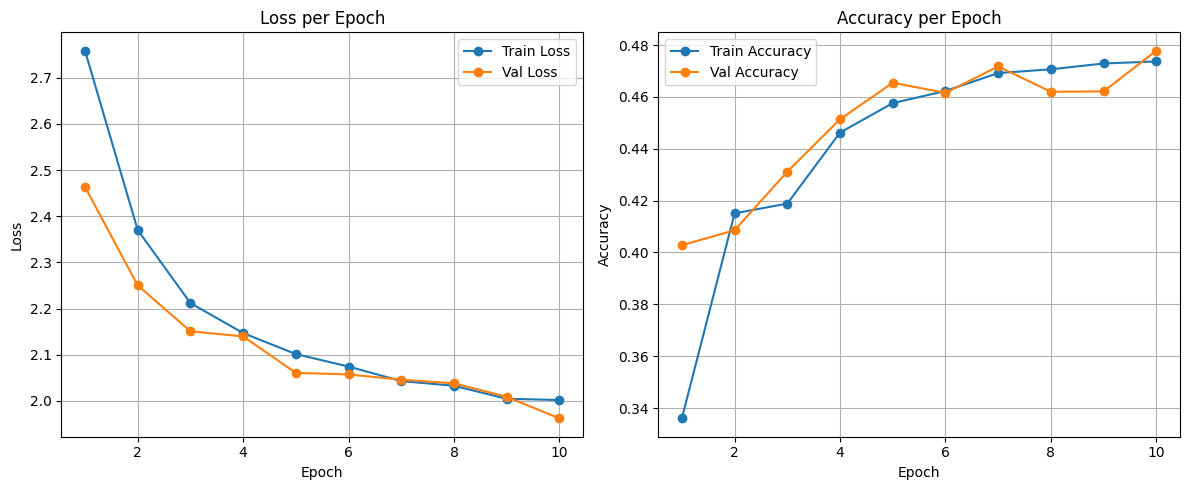

In [ ]:
epochs = range(1, len(loss_train) + 1)

plt.figure(figsize=(12,5))

# ---- Loss plot ----
plt.subplot(1,2,1)
plt.plot(epochs, loss_train, marker='o', label="Train Loss")
plt.plot(epochs, loss_val, marker='o', label="Val Loss")
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# ---- Accuracy plot ----
plt.subplot(1,2,2)
plt.plot(epochs, acc_train, marker='o', label="Train Accuracy")
plt.plot(epochs, acc_val, marker='o', label="Val Accuracy")
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# TESTING WITH WHOLE IMAGES

In [23]:
class HypercolumnImageDataset(IterableDataset):
    def __init__(self, voc_loader, vgg_model, device="mps"):
        """
        voc_loader: DataLoader yielding (img_batch, label_batch)
        vgg_model: pretrained VGG feature extractor
        """

        self.voc_loader = voc_loader
        self.vgg = vgg_model.eval().to(device)
        self.device = device

    def __iter__(self):

        for img_batch, lbl_batch in self.voc_loader:

            img_batch = img_batch.to(self.device)
            lbl_batch = lbl_batch.to(self.device)

            # forward pass through VGG
            with torch.no_grad():
                feature_maps = extract_feature_maps(img_batch, self.vgg)
                hypercolumns = build_hypercolumns(feature_maps)  # [B, Z, H, W]

            yield hypercolumns, lbl_batch

In [24]:
IMG_BATCH_SIZE = 4 

# Hyperpixel pair dataset and loaders
train_image_dataset = HypercolumnImageDataset(voc_train_loader, vgg_model)
train_loader = DataLoader(train_image_dataset, batch_size=IMG_BATCH_SIZE, drop_last=True)

val_image_dataset = HypercolumnImageDataset(voc_val_loader, vgg_model)
val_loader = DataLoader(val_image_dataset, batch_size=IMG_BATCH_SIZE, drop_last=True)

test_image_dataset = HypercolumnImageDataset(voc_test_loader, vgg_model)
test_loader = DataLoader(test_image_dataset, batch_size=IMG_BATCH_SIZE, drop_last=True)

### TODO
Loaders here are serving batches the size of VOC Batch size. They are ignoring the IMG_BATCH_SIZE hyperparam.
Is this a problem?

I need to investigate whether having these differences matter lot. I believe that for inferencing, it really doesn't matter how big my bathes are since I'm not training. Batches only matter when I train.

In [27]:
img, lbl = next(iter(train_image_dataset))
img_test = img[0]
lbl_test = lbl[0]

In [31]:
out = hc_classifier(img_test)
pred_mask = torch.argmax(out, dim=0)

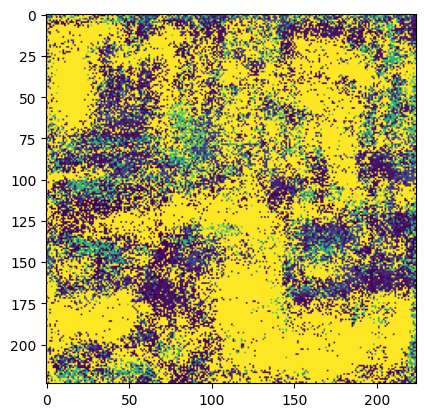

In [34]:
plt.imshow(pred_mask.cpu())

In [28]:
print(img_test.shape)
lbl_test.shape

torch.Size([960, 224, 224])


torch.Size([224, 224])

# Research (Understanding of the Task)

### Dataset
Images: random images of a variety of things. **They're different sizes!**
Labels: annotated segmentations, where pixels are labeled per the object class (does pixel belong to object? -> assign some number). Outlines are 255 and background is 0

### Architecture
Pre-trained VGG architecture (a CNN with multiple layers) 

### Training
For each pixel p in the original image:
1. Take feature maps from several layers.
2. Upsample them to the original resolution (bilinear interpolation).
3. Extract the vector at pixel p
4. Concatenate them.

However, we do this for a sample of pixels! Don't use all of them or else massive memory overhead; it would take forever.

(1) Instead of fine-tuning the entire system, fix the pre-trained CNN and learn a shallow classifier that acts on extracted hypercolumns. For this auxiliary classifier, you may experiment with different architectures, but general advice is to keep it below 10 layers (and maybe below 4 if training is too slow). This classifier should predict a softmax distribution over pixels, i.e. a H x W x C tensor where C is the number of classes.

(2) While at inference (test) time, your system should produce predictions for every pixel location in the image, this is unnecessary at training time.  Greater statistical efficiency during training is possible by subsampling a sparse set of locations per image at which to extract hypercolumns.  You can build a training set of hypercolumn features in an offline manner by, e.g.,
(i) For each training image, sample 3 pixels from each class.
(ii) For each pixel, save the pixel hypercolumn feature (i.e., 1x1xZ dimensional descriptor), along with the identity of that pixel as a label.
In the PASCAL VOC dataset, there are an average of 2.5 classes per image, so this process should yield around 10,000 example (feature, label) pairs.

### Loss Function

### Metrics